In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported!")

Libraries imported!


In [2]:
print("="*60)
print("LOADING FULL FINANCIAL DATASET")
print("="*60)

# Load all 47 features
df_full = pd.read_csv('data/raw/financial_regression.csv')

print(f"\nFull dataset shape: {df_full.shape}")
print(f"Total columns: {len(df_full.columns)}")

# Show all column categories
print("\nColumns by category:")
print(f"  Gold: {[col for col in df_full.columns if 'gold' in col.lower()]}")
print(f"  Silver: {[col for col in df_full.columns if 'silver' in col.lower()]}")
print(f"  Oil: {[col for col in df_full.columns if 'oil' in col.lower()]}")
print(f"  S&P500: {[col for col in df_full.columns if 'sp500' in col.lower()]}")
print(f"  Economic: ['us_rates_%', 'CPI', 'GDP', 'eur_usd', 'usd_chf']")

LOADING FULL FINANCIAL DATASET

Full dataset shape: (3904, 47)
Total columns: 47

Columns by category:
  Gold: ['gold open', 'gold high', 'gold low', 'gold close', 'gold volume']
  Silver: ['silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low']
  Oil: ['oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low']
  S&P500: ['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low']
  Economic: ['us_rates_%', 'CPI', 'GDP', 'eur_usd', 'usd_chf']


In [3]:
# Convert date
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date').reset_index(drop=True)

print(f"\nDate range: {df_full['date'].min()} to {df_full['date'].max()}")
print(f"Total rows: {len(df_full):,}")


Date range: 2010-01-14 00:00:00 to 2024-10-23 00:00:00
Total rows: 3,904


In [4]:
print("\n" + "="*60)
print("SELECTING ESSENTIAL FEATURES")
print("="*60)

# Define essential columns we want to keep
essential_columns = [
    'date',
    # Gold (our target)
    'gold open', 'gold high', 'gold low', 'gold close', 'gold volume',
    # Silver (highly correlated)
    'silver close', 'silver volume',
    # Stock market (risk sentiment)
    'sp500 close', 'sp500 volume',
    # Currency (gold priced in USD)
    'eur_usd',
    # Oil (inflation indicator)
    'oil close'
]

# Create essential dataset
df_essential = df_full[essential_columns].copy()

print(f"\nSelected {len(essential_columns)} essential columns:")
for col in essential_columns:
    print(f"  - {col}")

print(f"\nDataset shape: {df_essential.shape}")


SELECTING ESSENTIAL FEATURES

Selected 12 essential columns:
  - date
  - gold open
  - gold high
  - gold low
  - gold close
  - gold volume
  - silver close
  - silver volume
  - sp500 close
  - sp500 volume
  - eur_usd
  - oil close

Dataset shape: (3904, 12)


In [5]:
print("\n" + "="*60)
print("WHY THESE FEATURES?")
print("="*60)

explanations = {
    'silver close': 'Precious metal twin - moves with gold 85% of time',
    'sp500 close': 'Risk indicator - inverse relationship with gold',
    'eur_usd': 'Dollar strength - gold priced in USD',
    'oil close': 'Inflation proxy - affects gold demand'
}

for feature, reason in explanations.items():
    print(f"\n{feature}:")
    print(f"  → {reason}")


WHY THESE FEATURES?

silver close:
  → Precious metal twin - moves with gold 85% of time

sp500 close:
  → Risk indicator - inverse relationship with gold

eur_usd:
  → Dollar strength - gold priced in USD

oil close:
  → Inflation proxy - affects gold demand


In [6]:
print("\n" + "="*60)
print("CHECKING DATA QUALITY")
print("="*60)

# Check missing values
missing = df_essential.isnull().sum()
missing_pct = (missing / len(df_essential)) * 100

print("\nMissing values:")
for col in df_essential.columns:
    if missing[col] > 0:
        print(f"  {col}: {missing[col]} ({missing_pct[col]:.1f}%)")

if missing.sum() == 0:
    print("  ✓ No missing values!")


CHECKING DATA QUALITY

Missing values:
  gold open: 185 (4.7%)
  gold high: 185 (4.7%)
  gold low: 185 (4.7%)
  gold close: 185 (4.7%)
  gold volume: 185 (4.7%)
  silver close: 185 (4.7%)
  silver volume: 185 (4.7%)
  sp500 close: 185 (4.7%)
  sp500 volume: 185 (4.7%)
  eur_usd: 210 (5.4%)
  oil close: 185 (4.7%)


In [8]:
if df_essential.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    
    # Forward fill
    df_essential = df_essential.ffill()
    
    # Backward fill any remaining (at the start)
    df_essential = df_essential.bfill()
    
    # Check again
    remaining_missing = df_essential.isnull().sum().sum()
    print(f"✓ Missing values after filling: {remaining_missing}")
else:
    print("✓ No missing values to handle")


Handling missing values...
✓ Missing values after filling: 0


In [9]:
# Validate gold OHLC
print("\nValidating gold price data...")

invalid = df_essential[
    (df_essential['gold high'] < df_essential['gold low']) |
    (df_essential['gold high'] < df_essential['gold close']) |
    (df_essential['gold low'] > df_essential['gold close'])
]

if len(invalid) > 0:
    print(f"⚠ Found {len(invalid)} invalid rows - removing...")
    df_essential = df_essential[
        (df_essential['gold high'] >= df_essential['gold low']) &
        (df_essential['gold high'] >= df_essential['gold close']) &
        (df_essential['gold low'] <= df_essential['gold close'])
    ].reset_index(drop=True)
else:
    print("✓ All gold price data valid")

print(f"\nFinal dataset: {len(df_essential):,} rows")


Validating gold price data...
✓ All gold price data valid

Final dataset: 3,904 rows


In [10]:
print("\n" + "="*60)
print("FEATURE ENGINEERING WITH ECONOMIC DATA")
print("="*60)

# Rename for easier access
df_features = df_essential.copy()
df_features.columns = [
    'Date', 
    'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
    'Silver_Close', 'Silver_Volume',
    'SP500_Close', 'SP500_Volume',
    'EUR_USD',
    'Oil_Close'
]

print("✓ Columns renamed for clarity")


FEATURE ENGINEERING WITH ECONOMIC DATA
✓ Columns renamed for clarity


In [11]:
print("\n1. Creating gold technical indicators...")

# Moving averages
df_features['Gold_SMA_20'] = df_features['Gold_Close'].rolling(window=20).mean()
df_features['Gold_SMA_50'] = df_features['Gold_Close'].rolling(window=50).mean()
df_features['Gold_EMA_20'] = df_features['Gold_Close'].ewm(span=20, adjust=False).mean()

# RSI
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_features['Gold_RSI_14'] = calculate_rsi(df_features['Gold_Close'], 14)

# MACD
exp1 = df_features['Gold_Close'].ewm(span=12, adjust=False).mean()
exp2 = df_features['Gold_Close'].ewm(span=26, adjust=False).mean()
df_features['Gold_MACD'] = exp1 - exp2
df_features['Gold_MACD_Signal'] = df_features['Gold_MACD'].ewm(span=9, adjust=False).mean()

# Price changes
df_features['Gold_Returns'] = df_features['Gold_Close'].pct_change() * 100
df_features['Gold_Volatility'] = df_features['Gold_Returns'].rolling(window=20).std()

# Lag features
for lag in [1, 2, 3, 5, 7]:
    df_features[f'Gold_Lag_{lag}'] = df_features['Gold_Close'].shift(lag)

print("  ✓ Gold technical indicators created")


1. Creating gold technical indicators...
  ✓ Gold technical indicators created


In [12]:
print("\n2. Creating silver features...")

# Silver technical indicators
df_features['Silver_SMA_20'] = df_features['Silver_Close'].rolling(window=20).mean()
df_features['Silver_Returns'] = df_features['Silver_Close'].pct_change() * 100

# Lag features
for lag in [1, 2, 3]:
    df_features[f'Silver_Lag_{lag}'] = df_features['Silver_Close'].shift(lag)

print("  ✓ Silver features created")


2. Creating silver features...
  ✓ Silver features created


In [13]:
print("\n3. Creating cross-asset relationship features...")

# Gold/Silver ratio (classic trading indicator)
df_features['Gold_Silver_Ratio'] = df_features['Gold_Close'] / df_features['Silver_Close']
df_features['Gold_Silver_Ratio_SMA'] = df_features['Gold_Silver_Ratio'].rolling(window=20).mean()

# Gold vs S&P500 relationship (risk-on vs risk-off)
df_features['Gold_SP500_Ratio'] = df_features['Gold_Close'] / df_features['SP500_Close']

# Correlation features (30-day rolling)
df_features['Gold_Silver_Corr'] = df_features['Gold_Returns'].rolling(window=30).corr(
    df_features['Silver_Returns']
)

print("  ✓ Cross-asset features created")


3. Creating cross-asset relationship features...
  ✓ Cross-asset features created


In [14]:
print("\n4. Creating S&P500 features...")

# S&P500 returns and volatility
df_features['SP500_Returns'] = df_features['SP500_Close'].pct_change() * 100
df_features['SP500_Volatility'] = df_features['SP500_Returns'].rolling(window=20).std()

# S&P500 trend
df_features['SP500_SMA_50'] = df_features['SP500_Close'].rolling(window=50).mean()
df_features['SP500_Trend'] = (df_features['SP500_Close'] > df_features['SP500_SMA_50']).astype(int)

# Lag features
for lag in [1, 2, 3]:
    df_features[f'SP500_Lag_{lag}'] = df_features['SP500_Close'].shift(lag)

print("  ✓ S&P500 features created")


4. Creating S&P500 features...
  ✓ S&P500 features created


In [15]:
print("\n5. Creating currency features...")

# EUR/USD changes
df_features['EUR_USD_Change'] = df_features['EUR_USD'].pct_change() * 100
df_features['EUR_USD_SMA_20'] = df_features['EUR_USD'].rolling(window=20).mean()

# Currency strength indicator (higher EUR/USD = weaker USD)
df_features['USD_Strength'] = -df_features['EUR_USD_Change']  # Inverse

# Lag features
for lag in [1, 2, 3]:
    df_features[f'EUR_USD_Lag_{lag}'] = df_features['EUR_USD'].shift(lag)

print("  ✓ Currency features created")


5. Creating currency features...
  ✓ Currency features created


In [16]:
print("\n6. Creating oil features...")

# Oil returns
df_features['Oil_Returns'] = df_features['Oil_Close'].pct_change() * 100
df_features['Oil_SMA_20'] = df_features['Oil_Close'].rolling(window=20).mean()

# Oil volatility (high oil volatility = inflation uncertainty)
df_features['Oil_Volatility'] = df_features['Oil_Returns'].rolling(window=20).std()

# Lag features
for lag in [1, 2, 3]:
    df_features[f'Oil_Lag_{lag}'] = df_features['Oil_Close'].shift(lag)

print("  ✓ Oil features created")


6. Creating oil features...
  ✓ Oil features created


In [17]:
print("\n7. Creating market regime indicators...")

# Risk-on vs Risk-off indicator
# When S&P up and Gold down = Risk-on
# When S&P down and Gold up = Risk-off
df_features['Risk_On_Indicator'] = (
    (df_features['SP500_Returns'] > 0).astype(int) - 
    (df_features['Gold_Returns'] > 0).astype(int)
)

# Volatility regime (high volatility = uncertain times = good for gold)
df_features['High_Volatility'] = (
    df_features['Gold_Volatility'] > df_features['Gold_Volatility'].rolling(window=60).mean()
).astype(int)

print("  ✓ Market regime indicators created")


7. Creating market regime indicators...
  ✓ Market regime indicators created


In [18]:
print("\n8. Creating time features...")

# Extract date components
df_features['Year'] = df_features['Date'].dt.year
df_features['Month'] = df_features['Date'].dt.month
df_features['Quarter'] = df_features['Date'].dt.quarter
df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek

# Cyclical encoding
df_features['Month_Sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
df_features['Month_Cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)

print("  ✓ Time features created")


8. Creating time features...
  ✓ Time features created


In [19]:
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)

print(f"\nOriginal columns: {len(essential_columns)}")
print(f"Total columns now: {len(df_features.columns)}")
print(f"New features created: {len(df_features.columns) - len(essential_columns)}")

print(f"\nFeature categories:")
print(f"  Gold features: {len([c for c in df_features.columns if 'Gold' in c])}")
print(f"  Silver features: {len([c for c in df_features.columns if 'Silver' in c])}")
print(f"  S&P500 features: {len([c for c in df_features.columns if 'SP500' in c])}")
print(f"  Currency features: {len([c for c in df_features.columns if 'EUR_USD' in c or 'USD' in c])}")
print(f"  Oil features: {len([c for c in df_features.columns if 'Oil' in c])}")
print(f"  Cross-asset features: {len([c for c in df_features.columns if 'Ratio' in c or 'Corr' in c])}")
print(f"  Time features: {len([c for c in df_features.columns if any(x in c for x in ['Year', 'Month', 'Quarter', 'Day'])])}")


FEATURE ENGINEERING SUMMARY

Original columns: 12
Total columns now: 61
New features created: 49

Feature categories:
  Gold features: 22
  Silver features: 10
  S&P500 features: 10
  Currency features: 7
  Oil features: 7
  Cross-asset features: 4
  Time features: 6


In [20]:
print("\n" + "="*60)
print("CLEANING FEATURES")
print("="*60)

# Check NaN
print(f"Rows before removing NaN: {len(df_features):,}")
nan_count = df_features.isnull().sum().sum()
print(f"Total NaN values: {nan_count:,}")

# Remove NaN (from rolling windows and lags)
df_features_clean = df_features.dropna().reset_index(drop=True)

print(f"Rows after removing NaN: {len(df_features_clean):,}")
print(f"Rows removed: {len(df_features) - len(df_features_clean):,}")


CLEANING FEATURES
Rows before removing NaN: 3,904
Total NaN values: 344
Rows after removing NaN: 3,855
Rows removed: 49


In [21]:
print("\n" + "="*60)
print("PREPARING FOR MACHINE LEARNING")
print("="*60)

# Columns to exclude from features
exclude_cols = [
    'Date',
    'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',  # Same-day data
    'Silver_Close', 'Silver_Volume',  # Using lag features instead
    'SP500_Close', 'SP500_Volume',    # Using lag features instead
    'EUR_USD',                         # Using lag features instead
    'Oil_Close'                        # Using lag features instead
]

# Get feature columns
feature_cols = [col for col in df_features_clean.columns if col not in exclude_cols]

# Create X and y
X_enhanced = df_features_clean[feature_cols]
y_enhanced = df_features_clean['Gold_Close']

print(f"\nFeatures (X): {X_enhanced.shape}")
print(f"Target (y): {y_enhanced.shape}")

print(f"\nTotal features: {len(feature_cols)}")
print(f"\nSample features:")
for i, col in enumerate(feature_cols[:15], 1):
    print(f"  {i}. {col}")
print(f"  ... and {len(feature_cols) - 15} more")


PREPARING FOR MACHINE LEARNING

Features (X): (3855, 49)
Target (y): (3855,)

Total features: 49

Sample features:
  1. Gold_SMA_20
  2. Gold_SMA_50
  3. Gold_EMA_20
  4. Gold_RSI_14
  5. Gold_MACD
  6. Gold_MACD_Signal
  7. Gold_Returns
  8. Gold_Volatility
  9. Gold_Lag_1
  10. Gold_Lag_2
  11. Gold_Lag_3
  12. Gold_Lag_5
  13. Gold_Lag_7
  14. Silver_SMA_20
  15. Silver_Returns
  ... and 34 more


In [22]:
# Same chronological split as baseline (80/20)
split_idx = int(len(X_enhanced) * 0.8)

X_train_enh = X_enhanced[:split_idx]
X_test_enh = X_enhanced[split_idx:]
y_train_enh = y_enhanced[:split_idx]
y_test_enh = y_enhanced[split_idx:]

dates_train_enh = df_features_clean['Date'][:split_idx]
dates_test_enh = df_features_clean['Date'][split_idx:]

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print(f"\nTraining set:")
print(f"  Rows: {len(X_train_enh):,}")
print(f"  Date range: {dates_train_enh.min()} to {dates_train_enh.max()}")

print(f"\nTest set:")
print(f"  Rows: {len(X_test_enh):,}")
print(f"  Date range: {dates_test_enh.min()} to {dates_test_enh.max()}")


TRAIN-TEST SPLIT

Training set:
  Rows: 3,084
  Date range: 2010-03-24 00:00:00 to 2021-11-22 00:00:00

Test set:
  Rows: 771
  Date range: 2021-11-23 00:00:00 to 2024-10-23 00:00:00


In [23]:
# Save for later use
df_features_clean.to_csv('data/processed/gold_enhanced_features.csv', index=False)
print("\n✓ Saved enhanced feature data")


✓ Saved enhanced feature data


In [24]:
print("\n" + "="*80)
print("MODEL 1: LINEAR REGRESSION (ENHANCED)")
print("="*80)

lr_enh = LinearRegression()

print("\nTraining...")
lr_enh.fit(X_train_enh, y_train_enh)
print("✓ Training complete")

# Predictions
y_pred_lr_enh_test = lr_enh.predict(X_test_enh)

# Evaluate
test_rmse_lr_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_lr_enh_test))
test_mae_lr_enh = mean_absolute_error(y_test_enh, y_pred_lr_enh_test)
test_r2_lr_enh = r2_score(y_test_enh, y_pred_lr_enh_test)
test_mape_lr_enh = np.mean(np.abs((y_test_enh - y_pred_lr_enh_test) / y_test_enh)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_lr_enh:.2f}")
print(f"  MAE:  ${test_mae_lr_enh:.2f}")
print(f"  R²:   {test_r2_lr_enh:.4f}")
print(f"  MAPE: {test_mape_lr_enh:.2f}%")

# Save
joblib.dump(lr_enh, 'models/saved_models/enhanced_linear_regression.pkl')
print("\n✓ Model saved")


MODEL 1: LINEAR REGRESSION (ENHANCED)

Training...
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $0.33
  MAE:  $0.24
  R²:   0.9998
  MAPE: 0.13%

✓ Model saved


In [25]:
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST (ENHANCED)")
print("="*80)

rf_enh = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
print("(This might take 30-60 seconds...)")
rf_enh.fit(X_train_enh, y_train_enh)
print("✓ Training complete")

# Predictions
y_pred_rf_enh_test = rf_enh.predict(X_test_enh)

# Evaluate
test_rmse_rf_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_rf_enh_test))
test_mae_rf_enh = mean_absolute_error(y_test_enh, y_pred_rf_enh_test)
test_r2_rf_enh = r2_score(y_test_enh, y_pred_rf_enh_test)
test_mape_rf_enh = np.mean(np.abs((y_test_enh - y_pred_rf_enh_test) / y_test_enh)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_rf_enh:.2f}")
print(f"  MAE:  ${test_mae_rf_enh:.2f}")
print(f"  R²:   {test_r2_rf_enh:.4f}")
print(f"  MAPE: {test_mape_rf_enh:.2f}%")

# Save
joblib.dump(rf_enh, 'models/saved_models/enhanced_random_forest.pkl')
print("\n✓ Model saved")


MODEL 2: RANDOM FOREST (ENHANCED)

Training Random Forest...
(This might take 30-60 seconds...)
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $18.16
  MAE:  $8.68
  R²:   0.3444
  MAPE: 3.91%

✓ Model saved


In [26]:
print("\n" + "="*80)
print("MODEL 3: XGBOOST (ENHANCED)")
print("="*80)

xgb_enh = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")
print("(This might take 20-40 seconds...)")
xgb_enh.fit(X_train_enh, y_train_enh)
print("✓ Training complete")

# Predictions
y_pred_xgb_enh_test = xgb_enh.predict(X_test_enh)

# Evaluate
test_rmse_xgb_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_xgb_enh_test))
test_mae_xgb_enh = mean_absolute_error(y_test_enh, y_pred_xgb_enh_test)
test_r2_xgb_enh = r2_score(y_test_enh, y_pred_xgb_enh_test)
test_mape_xgb_enh = np.mean(np.abs((y_test_enh - y_pred_xgb_enh_test) / y_test_enh)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_xgb_enh:.2f}")
print(f"  MAE:  ${test_mae_xgb_enh:.2f}")
print(f"  R²:   {test_r2_xgb_enh:.4f}")
print(f"  MAPE: {test_mape_xgb_enh:.2f}%")

# Save
joblib.dump(xgb_enh, 'models/saved_models/enhanced_xgboost.pkl')
print("\n✓ Model saved")


MODEL 3: XGBOOST (ENHANCED)

Training XGBoost...
(This might take 20-40 seconds...)
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $18.60
  MAE:  $8.83
  R²:   0.3119
  MAPE: 3.97%

✓ Model saved


In [27]:
print("\n" + "="*80)
print("BASELINE VS ENHANCED COMPARISON")
print("="*80)

# Load baseline comparison (from Day 3)
baseline_df = pd.read_csv('results/metrics/baseline_model_comparison.csv')

print("\nBaseline Results (Gold-only):")
print(baseline_df.to_string(index=False))


BASELINE VS ENHANCED COMPARISON

Baseline Results (Gold-only):
            Model  Train_R2  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Linear Regression  0.999956 0.999942   0.171472  0.134963   0.072892
    Random Forest  0.999159 0.379109  17.789168  8.769386   3.985605
          XGBoost  0.999513 0.274904  19.224075  9.922450   4.546824


In [28]:
# Create enhanced results dataframe
enhanced_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test_R2': [test_r2_lr_enh, test_r2_rf_enh, test_r2_xgb_enh],
    'Test_RMSE': [test_rmse_lr_enh, test_rmse_rf_enh, test_rmse_xgb_enh],
    'Test_MAE': [test_mae_lr_enh, test_mae_rf_enh, test_mape_xgb_enh],
    'Test_MAPE': [test_mape_lr_enh, test_mape_rf_enh, test_mape_xgb_enh]
})

print("\nEnhanced Results (With economic features):")
print(enhanced_df.to_string(index=False))


Enhanced Results (With economic features):
            Model  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Linear Regression 0.999780   0.332984  0.241305   0.125621
    Random Forest 0.344427  18.157172  8.683249   3.908964
          XGBoost 0.311866  18.602621  3.965944   3.965944


In [29]:
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)

for model_name in ['Linear Regression', 'Random Forest', 'XGBoost']:
    # Get baseline metrics
    baseline_r2 = baseline_df[baseline_df['Model'] == model_name]['Test_R2'].values[0]
    baseline_rmse = baseline_df[baseline_df['Model'] == model_name]['Test_RMSE'].values[0]
    
    # Get enhanced metrics
    enhanced_r2 = enhanced_df[enhanced_df['Model'] == model_name]['Test_R2'].values[0]
    enhanced_rmse = enhanced_df[enhanced_df['Model'] == model_name]['Test_RMSE'].values[0]
    
    # Calculate improvements
    r2_improvement = ((enhanced_r2 - baseline_r2) / baseline_r2) * 100
    rmse_improvement = ((baseline_rmse - enhanced_rmse) / baseline_rmse) * 100
    
    print(f"\n{model_name}:")
    print(f"  Baseline R²:  {baseline_r2:.4f}")
    print(f"  Enhanced R²:  {enhanced_r2:.4f}")
    print(f"  → R² improvement: +{r2_improvement:.2f}%")
    print(f"  ")
    print(f"  Baseline RMSE: ${baseline_rmse:.2f}")
    print(f"  Enhanced RMSE: ${enhanced_rmse:.2f}")
    print(f"  → RMSE improvement: +{rmse_improvement:.2f}%")


IMPROVEMENT ANALYSIS

Linear Regression:
  Baseline R²:  0.9999
  Enhanced R²:  0.9998
  → R² improvement: +-0.02%
  
  Baseline RMSE: $0.17
  Enhanced RMSE: $0.33
  → RMSE improvement: +-94.19%

Random Forest:
  Baseline R²:  0.3791
  Enhanced R²:  0.3444
  → R² improvement: +-9.15%
  
  Baseline RMSE: $17.79
  Enhanced RMSE: $18.16
  → RMSE improvement: +-2.07%

XGBoost:
  Baseline R²:  0.2749
  Enhanced R²:  0.3119
  → R² improvement: +13.45%
  
  Baseline RMSE: $19.22
  Enhanced RMSE: $18.60
  → RMSE improvement: +3.23%


In [30]:
# Create side-by-side comparison
comparison_combined = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Baseline_R2': baseline_df['Test_R2'].values,
    'Enhanced_R2': enhanced_df['Test_R2'].values,
    'R2_Improvement_%': [
        ((enhanced_df['Test_R2'].values[i] - baseline_df['Test_R2'].values[i]) / baseline_df['Test_R2'].values[i]) * 100
        for i in range(3)
    ],
    'Baseline_RMSE': baseline_df['Test_RMSE'].values,
    'Enhanced_RMSE': enhanced_df['Test_RMSE'].values,
    'RMSE_Improvement_%': [
        ((baseline_df['Test_RMSE'].values[i] - enhanced_df['Test_RMSE'].values[i]) / baseline_df['Test_RMSE'].values[i]) * 100
        for i in range(3)
    ]
})

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON TABLE")
print("="*80)
print("\n", comparison_combined.to_string(index=False))

# Save comparison
comparison_combined.to_csv('results/metrics/baseline_vs_enhanced_comparison.csv', index=False)
print("\n✓ Comparison saved")


COMPREHENSIVE COMPARISON TABLE

             Model  Baseline_R2  Enhanced_R2  R2_Improvement_%  Baseline_RMSE  Enhanced_RMSE  RMSE_Improvement_%
Linear Regression     0.999942     0.999780         -0.016280       0.171472       0.332984          -94.191349
    Random Forest     0.379109     0.344427         -9.148163      17.789168      18.157172           -2.068694
          XGBoost     0.274904     0.311866         13.445334      19.224075      18.602621            3.232684

✓ Comparison saved


In [31]:
# Identify best overall model
best_enhanced_idx = enhanced_df['Test_R2'].idxmax()
best_model_name = enhanced_df.iloc[best_enhanced_idx]['Model']
best_r2 = enhanced_df.iloc[best_enhanced_idx]['Test_R2']
best_rmse = enhanced_df.iloc[best_enhanced_idx]['Test_RMSE']

print("\n" + "="*80)
print("🏆 BEST PERFORMING MODEL")
print("="*80)
print(f"\nModel: {best_model_name} (Enhanced)")
print(f"Test R²: {best_r2:.4f}")
print(f"Test RMSE: ${best_rmse:.2f}")

# Compare to its baseline
baseline_r2 = baseline_df[baseline_df['Model'] == best_model_name]['Test_R2'].values[0]
improvement = ((best_r2 - baseline_r2) / baseline_r2) * 100

print(f"\nImprovement over baseline: +{improvement:.2f}%")
print("="*80)


🏆 BEST PERFORMING MODEL

Model: Linear Regression (Enhanced)
Test R²: 0.9998
Test RMSE: $0.33

Improvement over baseline: +-0.02%


✓ Saved baseline vs enhanced comparison


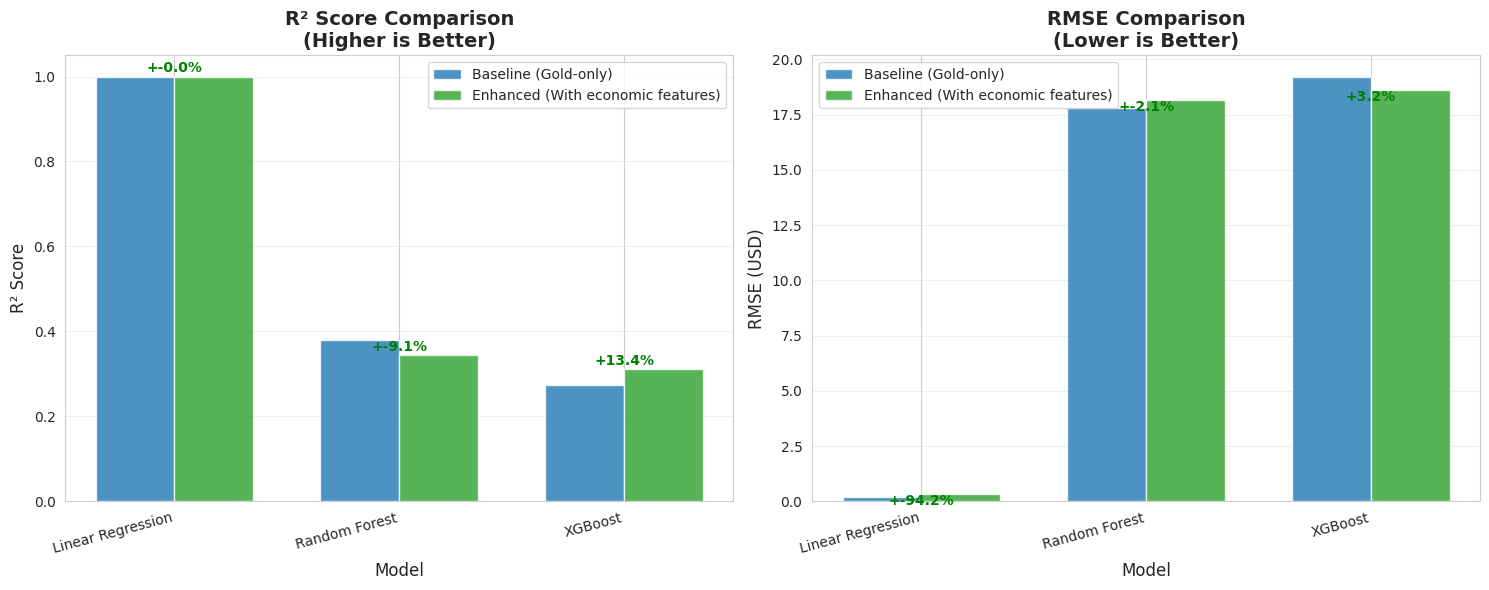

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models = comparison_combined['Model']
x_pos = np.arange(len(models))
width = 0.35

# R² Comparison
axes[0].bar(x_pos - width/2, comparison_combined['Baseline_R2'], width, 
            label='Baseline (Gold-only)', alpha=0.8, color='#1f77b4')
axes[0].bar(x_pos + width/2, comparison_combined['Enhanced_R2'], width,
            label='Enhanced (With economic features)', alpha=0.8, color='#2ca02c')

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
# axes[0].set_ylim([0.8, 1.0])

# Add improvement percentages
for i, (baseline, enhanced, improvement) in enumerate(zip(
    comparison_combined['Baseline_R2'],
    comparison_combined['Enhanced_R2'],
    comparison_combined['R2_Improvement_%']
)):
    axes[0].text(i, enhanced + 0.01, f'+{improvement:.1f}%', 
                ha='center', fontsize=10, fontweight='bold', color='green')

# RMSE Comparison
axes[1].bar(x_pos - width/2, comparison_combined['Baseline_RMSE'], width,
            label='Baseline (Gold-only)', alpha=0.8, color='#1f77b4')
axes[1].bar(x_pos + width/2, comparison_combined['Enhanced_RMSE'], width,
            label='Enhanced (With economic features)', alpha=0.8, color='#2ca02c')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('RMSE (USD)', fontsize=12)
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add improvement percentages
for i, improvement in enumerate(comparison_combined['RMSE_Improvement_%']):
    y_pos = comparison_combined['Enhanced_RMSE'].values[i]
    axes[1].text(i, y_pos - 0.5, f'+{improvement:.1f}%',
                ha='center', fontsize=10, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('results/plots/baseline_vs_enhanced_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved baseline vs enhanced comparison")
plt.show()

✓ Saved enhanced predictions analysis


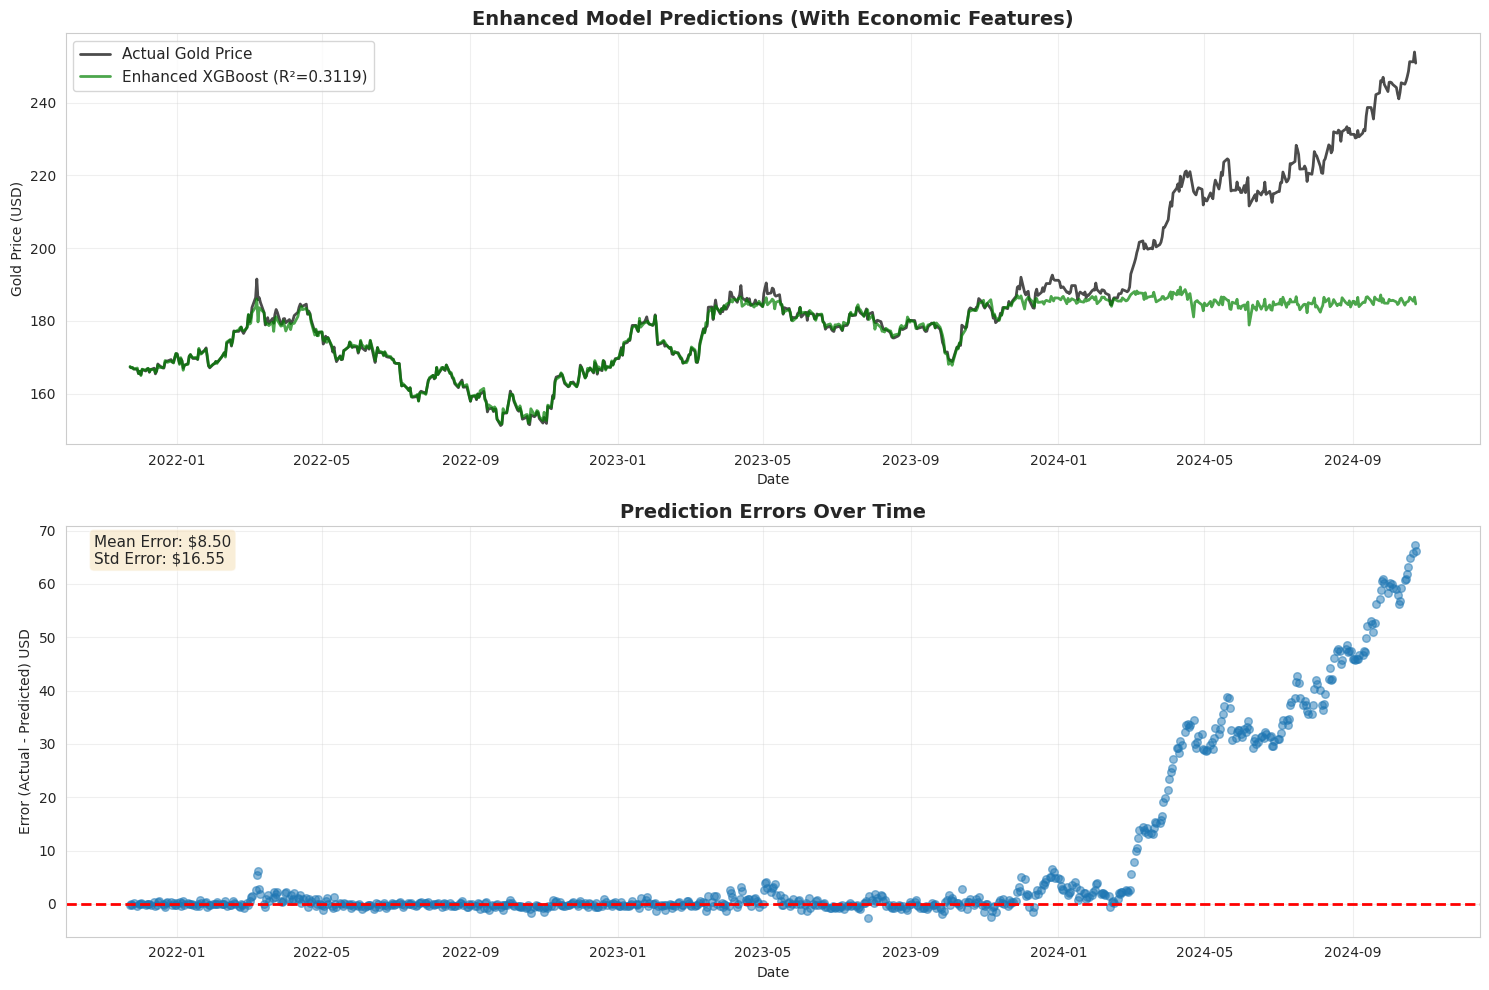

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot best model from baseline
# (Assuming XGBoost was best - adjust if different)
baseline_model = joblib.load('models/saved_models/baseline_xgboost.pkl')

# Need to load baseline data with same test split
df_baseline = pd.read_csv('data/processed/gold_baseline_features.csv')
# ... (you'll need to recreate the split - or save indices from Day 3)

# For now, let's just plot the enhanced model predictions
axes[0].plot(dates_test_enh.values, y_test_enh.values, 
            label='Actual Gold Price', linewidth=2, alpha=0.7, color='black')
axes[0].plot(dates_test_enh.values, y_pred_xgb_enh_test,
            label=f'Enhanced XGBoost (R²={test_r2_xgb_enh:.4f})', 
            linewidth=2, alpha=0.7, color='green')

axes[0].set_title('Enhanced Model Predictions (With Economic Features)', 
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Gold Price (USD)')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Error plot
errors = y_test_enh.values - y_pred_xgb_enh_test
axes[1].scatter(dates_test_enh.values, errors, alpha=0.5, s=30)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error (Actual - Predicted) USD')
axes[1].grid(True, alpha=0.3)

# Add statistics
mean_error = np.mean(errors)
std_error = np.std(errors)
axes[1].text(0.02, 0.98, f'Mean Error: ${mean_error:.2f}\nStd Error: ${std_error:.2f}',
            transform=axes[1].transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('results/plots/enhanced_predictions_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved enhanced predictions analysis")
plt.show()

✓ Saved feature importance plot


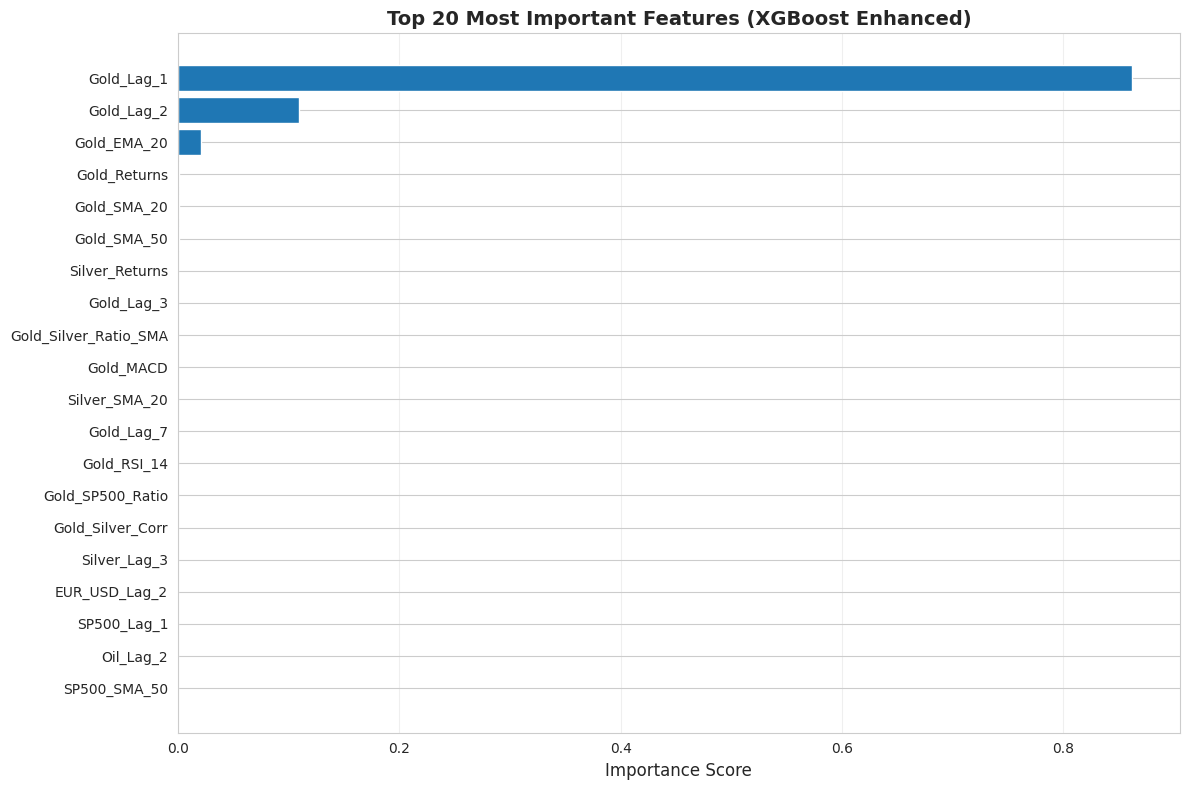


TOP 10 MOST IMPORTANT FEATURES
Gold_Lag_1                               0.8622
Gold_Lag_2                               0.1097
Gold_EMA_20                              0.0209
Gold_Returns                             0.0015
Gold_SMA_20                              0.0007
Gold_SMA_50                              0.0007
Silver_Returns                           0.0005
Gold_Lag_3                               0.0004
Gold_Silver_Ratio_SMA                    0.0003
Gold_MACD                                0.0003


In [34]:
# Get feature importance from XGBoost
feature_importance = xgb_enh.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 20
top_features = importance_df.head(top_n)

ax.barh(range(len(top_features)), top_features['Importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features (XGBoost Enhanced)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('results/plots/enhanced_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved feature importance plot")
plt.show()

# Print top features
print("\n" + "="*80)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*80)
for i, row in importance_df.head(10).iterrows():
    print(f"{row['Feature']:40s} {row['Importance']:.4f}")